**File:** `historical_scheme_data.csv`

This notebook looks at historical housing/plot schemes (projects) — pricing, amenities,
advertising spend, and how successful each scheme was.

Kept simple: basic pandas + seaborn only. Chart types are mixed on purpose (histogram,
boxplot, countplot, barplot, scatterplot, pie chart) instead of using one type for
everything.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 60)


In [ ]:
schemes = pd.read_csv('../data/processed/historical_scheme_data.csv')
print("Shape:", schemes.shape)
schemes.head()


Shape: (800, 16)


,Scheme_ID,Location,Plot_Size_SqFt,Price_INR,Monthly_EMI_INR,Park,Clubhouse,Distance_from_Metro_km,Advertising_Budget_INR,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Demand_Level,Scheme_Success_Score,Target_Age_Group,Most_Likely_Buyers
0,SCH_0101,Delhi (Outer/Bawana),800,1320000,9200,Yes,No,3.9,1500000,3230,602,18.6,HIGH,79,25-38,First-time Buyers & Investors
1,SCH_0102,Gurugram (SPR/Sohna),1800,8270000,57400,Yes,Yes,16.2,1500000,2335,348,14.9,HIGH,79,40-60,Affluent Investors & Luxury Homes
2,SCH_0103,Kolkata (New Town/Rajarhat),1500,3030000,21000,Yes,No,5.5,750000,1267,227,17.9,MEDIUM,74,25-38,First-time Buyers & Investors
3,SCH_0104,Bengaluru (North),1000,6360000,44200,Yes,No,23.9,1000000,1015,99,9.8,LOW,41,32-48,Self-use (Villa) + Investment
4,SCH_0105,Greater Noida,2400,8150000,56600,No,No,23.4,1000000,1180,73,6.2,LOW,25,40-60,Affluent Investors & Luxury Homes


In [ ]:
schemes.describe()


,Plot_Size_SqFt,Price_INR,Monthly_EMI_INR,Distance_from_Metro_km,Advertising_Budget_INR,Expected_Leads,Expected_Bookings,Estimated_Conversion_Pct,Scheme_Success_Score
count,800.000000,8.000000e+02,800.000000,800.000000,8.000000e+02,800.000000,800.000000,800.000000,800.000000
mean,1634.750000,5.597012e+06,38865.000000,14.830375,9.160625e+05,1221.776250,174.640000,13.825500,57.352500
std,711.670944,3.231329e+06,22437.541735,7.389153,6.166049e+05,882.878693,148.187034,3.497759,17.067656
min,800.000000,1.280000e+06,8900.000000,1.200000,2.000000e+05,102.000000,7.000000,5.700000,20.000000
25%,1000.000000,3.237500e+06,22475.000000,8.575000,3.500000e+05,475.000000,62.750000,11.300000,44.000000
50%,1500.000000,4.740000e+06,32900.000000,15.000000,7.500000e+05,985.500000,133.500000,13.650000,58.000000
75%,2400.000000,7.050000e+06,49000.000000,21.000000,1.500000e+06,1796.750000,244.250000,16.100000,71.000000
max,3000.000000,1.939000e+07,134600.000000,27.900000,2.000000e+06,4667.000000,1046.000000,25.200000,98.000000


## 1. Price, Plot size & Monthly EMI distribution

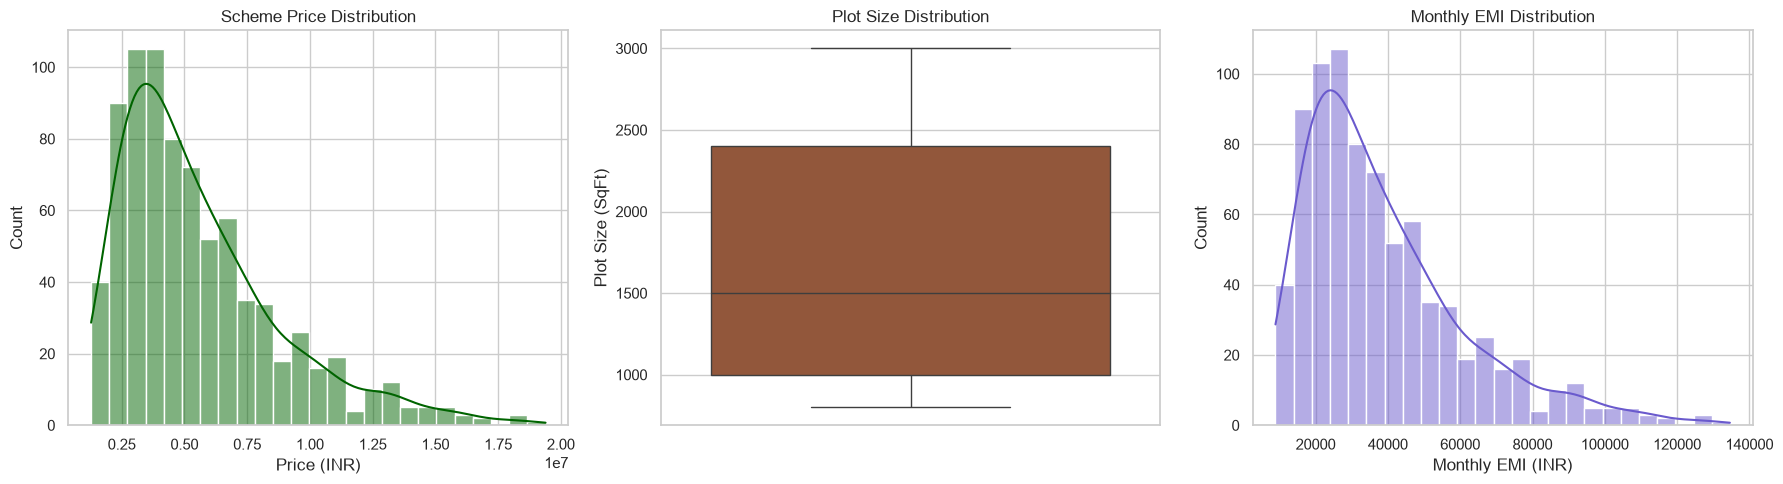

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Price Distribution
sns.histplot(schemes['Price_INR'], bins=25, kde=True, color='darkgreen', ax=axes[0])
axes[0].set_title('Scheme Price Distribution')
axes[0].set_xlabel('Price (INR)')

# Plot 2: Plot Size Distribution
sns.boxplot(y=schemes['Plot_Size_SqFt'], color='sienna', ax=axes[1])
axes[1].set_title('Plot Size Distribution')
axes[1].set_ylabel('Plot Size (SqFt)')

# Plot 3: Monthly EMI Distribution
sns.histplot(schemes['Monthly_EMI_INR'], bins=25, kde=True, color='slateblue', ax=axes[2])
axes[2].set_title('Monthly EMI Distribution')
axes[2].set_xlabel('Monthly EMI (INR)')

plt.savefig('../reports/figures/price-plot_size-monthly_emi.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

## 2. Price by Location 

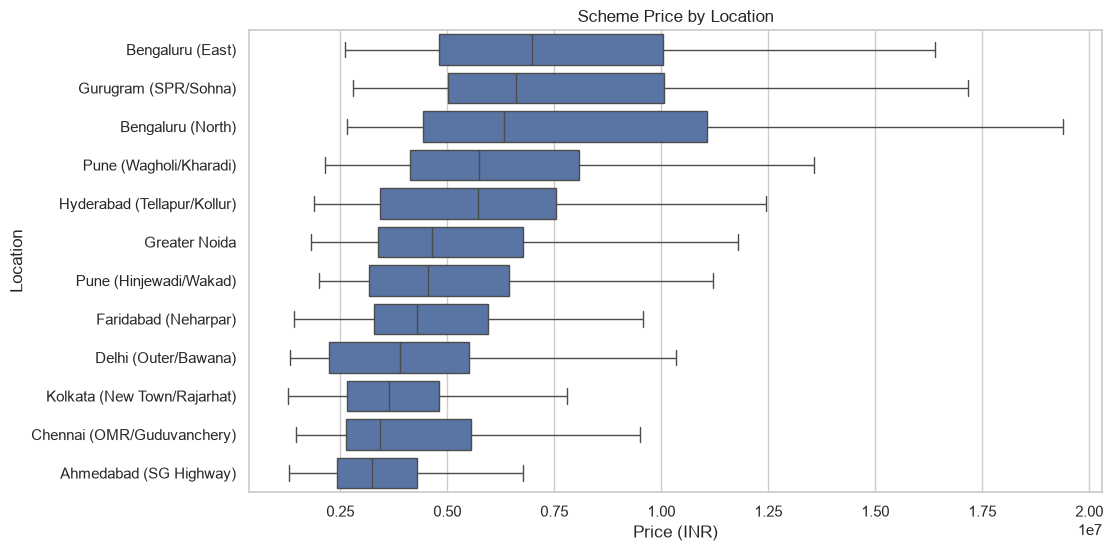

In [ ]:
plt.figure(figsize=(11, 6))
order_loc = schemes.groupby('Location')['Price_INR'].median().sort_values(ascending=False).index
sns.boxplot(data=schemes, x='Price_INR', y='Location', order=order_loc, showfliers=False)
plt.title('Scheme Price by Location')
plt.xlabel('Price (INR)')
plt.savefig('../reports/figures/price_by_location.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Plot size vs Price relationship

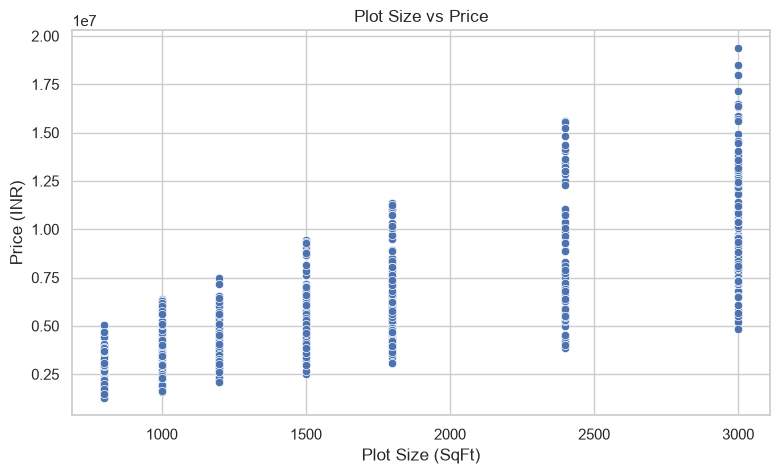

In [ ]:
plt.figure()
sns.scatterplot(data=schemes, x='Plot_Size_SqFt', y='Price_INR')
plt.title('Plot Size vs Price')
plt.xlabel('Plot Size (SqFt)')
plt.ylabel('Price (INR)')
plt.savefig('../reports/figures/plot_size-vs-price.png', dpi=300, bbox_inches='tight')
plt.show()


## 4. Distance from Metro 

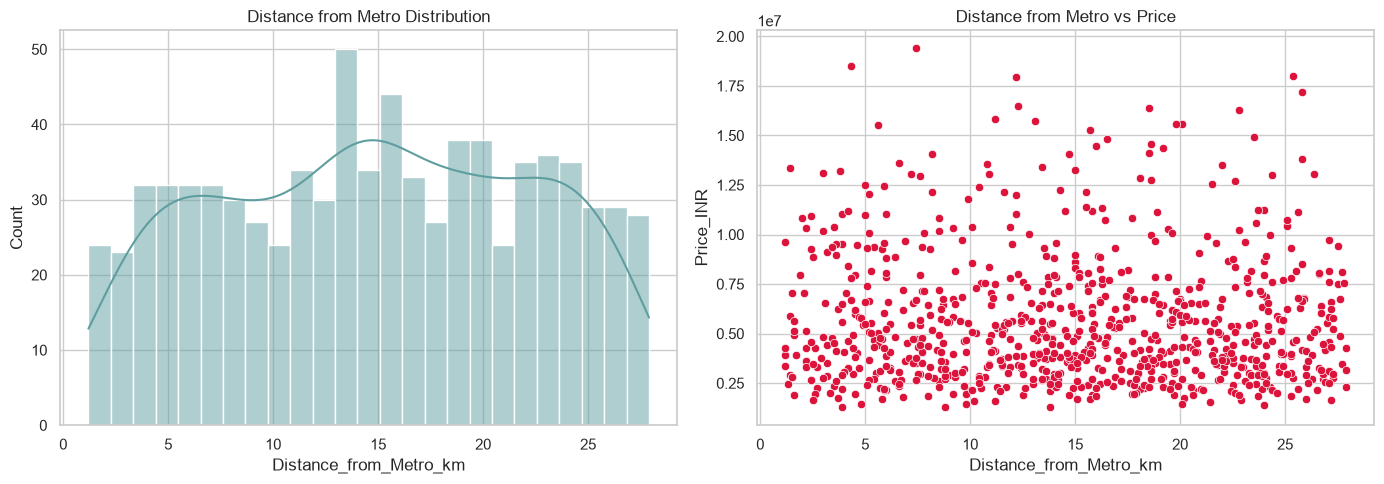

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(schemes['Distance_from_Metro_km'], bins=25, kde=True, ax=axes[0], color='cadetblue')
axes[0].set_title('Distance from Metro Distribution')

sns.scatterplot(data=schemes, x='Distance_from_Metro_km', y='Price_INR', ax=axes[1], color='crimson')
axes[1].set_title('Distance from Metro vs Price')

plt.savefig('../reports/figures/distance_from_metro.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 5. Demand level & Success score 

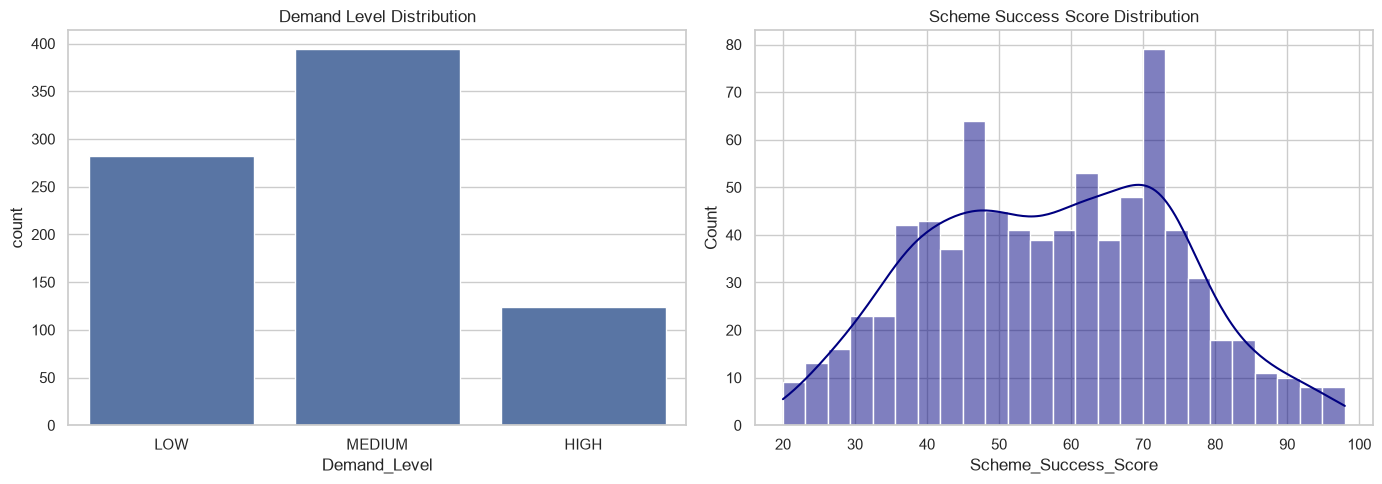

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=schemes, x='Demand_Level', order=['LOW', 'MEDIUM', 'HIGH'], ax=axes[0])
axes[0].set_title('Demand Level Distribution')

sns.histplot(schemes['Scheme_Success_Score'], bins=25, kde=True, ax=axes[1], color='navy')
axes[1].set_title('Scheme Success Score Distribution')

plt.savefig('../reports/figures/demand_level-success_score.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 6. Advertising budget vs Leads and Bookings

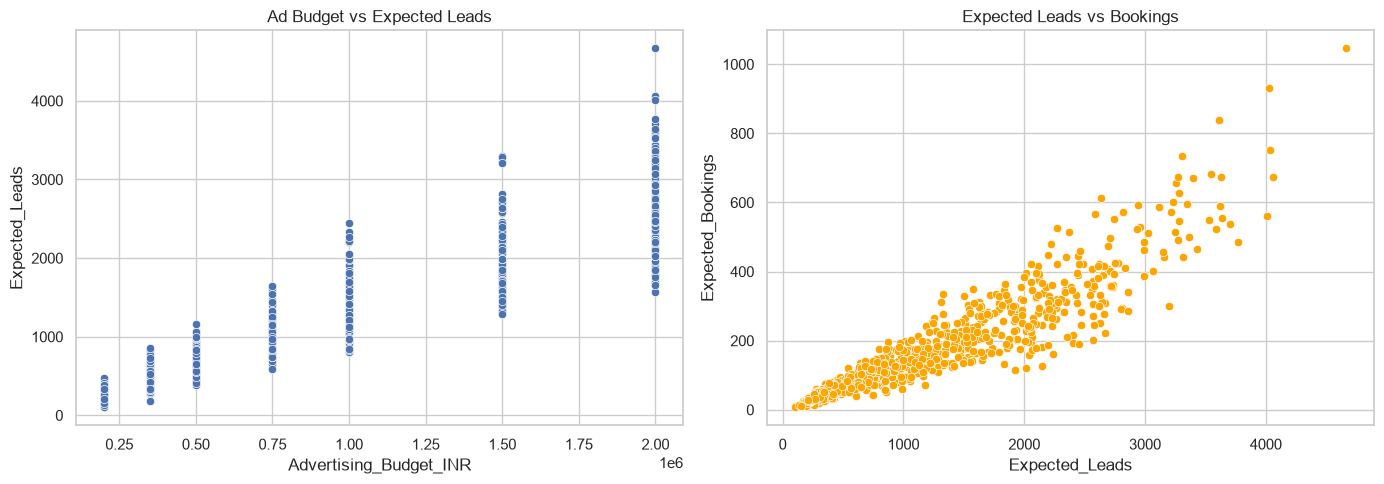

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=schemes, x='Advertising_Budget_INR', y='Expected_Leads', ax=axes[0])
axes[0].set_title('Ad Budget vs Expected Leads')

sns.scatterplot(data=schemes, x='Expected_Leads', y='Expected_Bookings', ax=axes[1], color='orange')
axes[1].set_title('Expected Leads vs Bookings')

plt.savefig('../reports/figures/budget-vs-leads-&-booking.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 7. Amenities : Park & Clubhouse

We group schemes by whether they have a Park/Clubhouse (Yes/No) and check the average
success score for each group, using plain `groupby().mean()`.


In [ ]:
park_success = schemes.groupby('Park')['Scheme_Success_Score'].mean()
clubhouse_success = schemes.groupby('Clubhouse')['Scheme_Success_Score'].mean()

print("Average success score by Park:")
print(park_success.round(1))
print()
print("Average success score by Clubhouse:")
print(clubhouse_success.round(1))


Average success score by Park:
Park
No     55.2
Yes    61.0
Name: Scheme_Success_Score, dtype: float64

Average success score by Clubhouse:
Clubhouse
No     53.2
Yes    72.0
Name: Scheme_Success_Score, dtype: float64


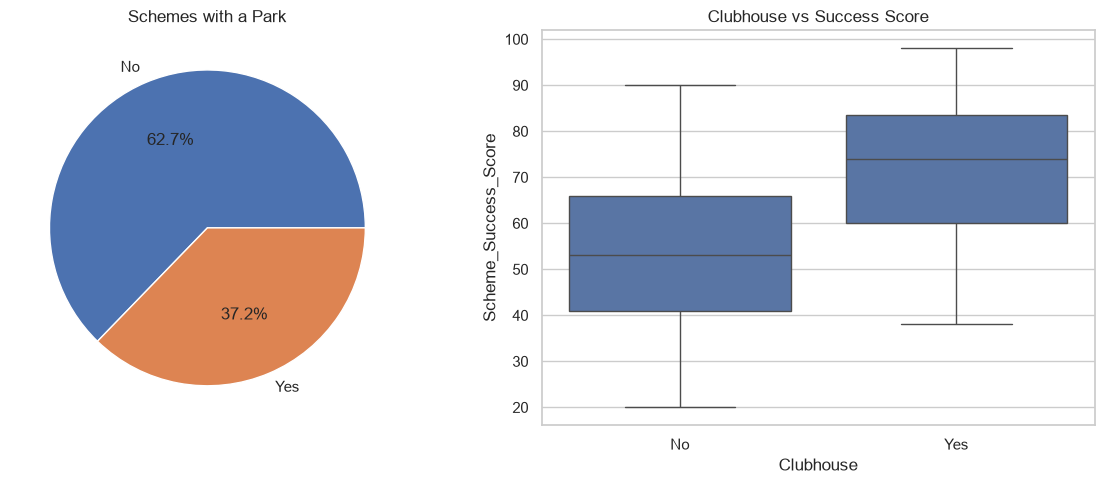

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

park_counts = schemes['Park'].value_counts()
axes[0].pie(park_counts, labels=park_counts.index, autopct='%1.1f%%')
axes[0].set_title('Schemes with a Park')

sns.boxplot(data=schemes, x='Clubhouse', y='Scheme_Success_Score', ax=axes[1])
axes[1].set_title('Clubhouse vs Success Score')

plt.savefig('../reports/figures/amenities-park-&-clubhouse.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 8. Target age group & most likely buyer segments

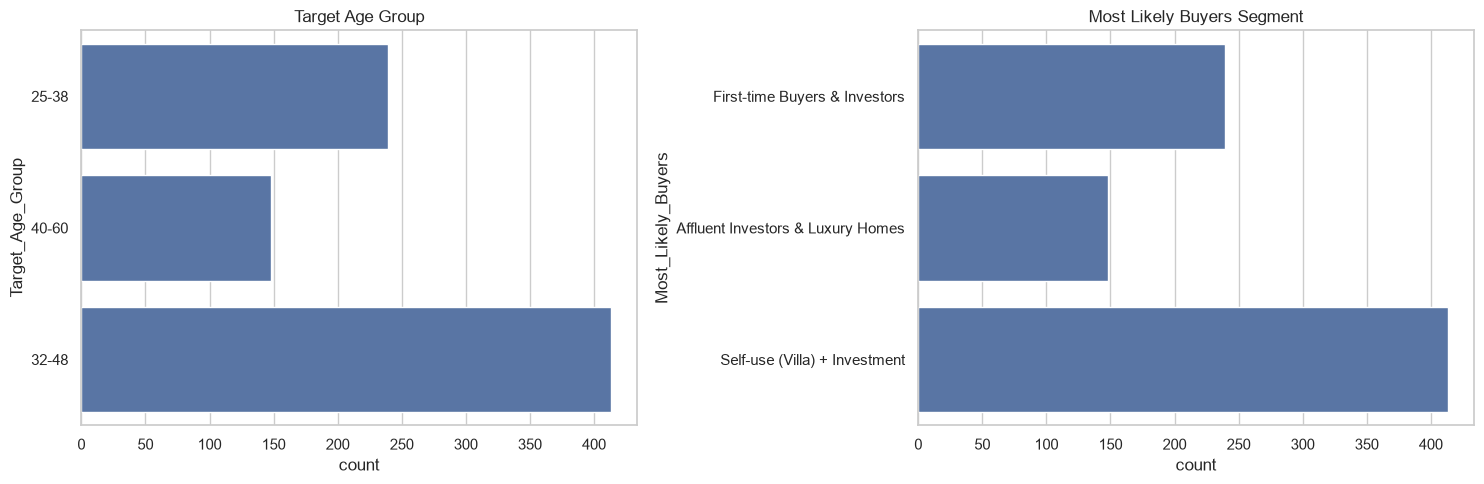

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=schemes, y='Target_Age_Group', ax=axes[0])
axes[0].set_title('Target Age Group')

sns.countplot(data=schemes, y='Most_Likely_Buyers', ax=axes[1])
axes[1].set_title('Most Likely Buyers Segment')

plt.savefig('../reports/figures/target_age-&-buyers.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


## 9. Success score by location

Location
Faridabad (Neharpar)           61.0
Greater Noida                  61.0
Delhi (Outer/Bawana)           61.0
Ahmedabad (SG Highway)         60.0
Pune (Wagholi/Kharadi)         59.5
Pune (Hinjewadi/Wakad)         59.0
Hyderabad (Tellapur/Kollur)    58.0
Kolkata (New Town/Rajarhat)    58.0
Gurugram (SPR/Sohna)           57.0
Chennai (OMR/Guduvanchery)     56.5
Bengaluru (North)              52.0
Bengaluru (East)               50.0
Name: Scheme_Success_Score, dtype: float64


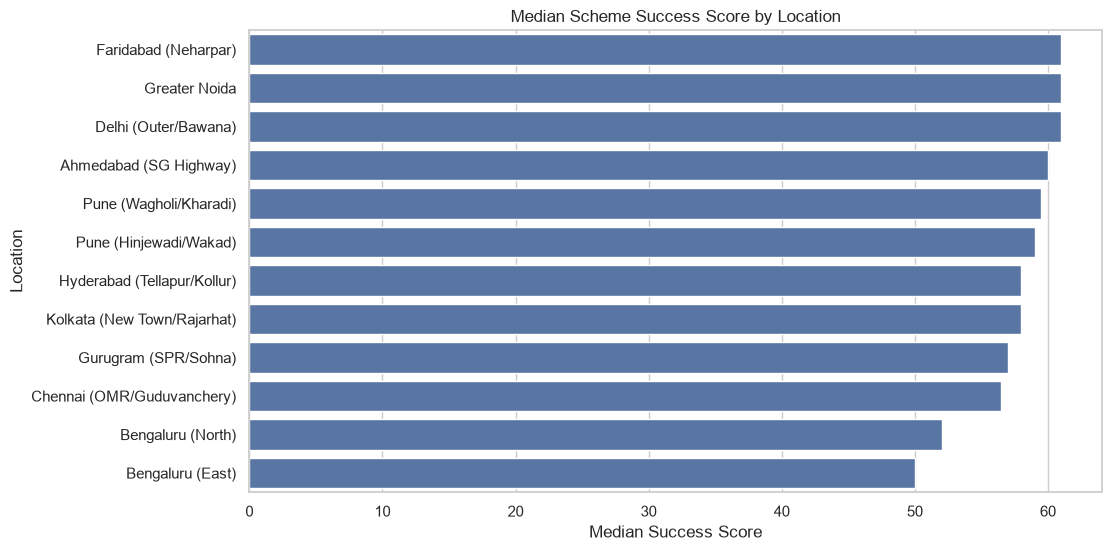

In [ ]:
location_success = schemes.groupby('Location')['Scheme_Success_Score'].median().sort_values(ascending=False)
print(location_success.round(1))

plt.figure(figsize=(11, 6))
sns.barplot(x=location_success.values, y=location_success.index)
plt.title('Median Scheme Success Score by Location')
plt.xlabel('Median Success Score')
plt.savefig('../reports/figures/Success_score(location).png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Correlation heatmap (numeric features)

This is directly useful for linear regression: it shows which numeric columns are related
to `Scheme_Success_Score` and to each other. Strongly correlated input columns can cause
multicollinearity, which is something you'll want to watch out for once you start
building models.


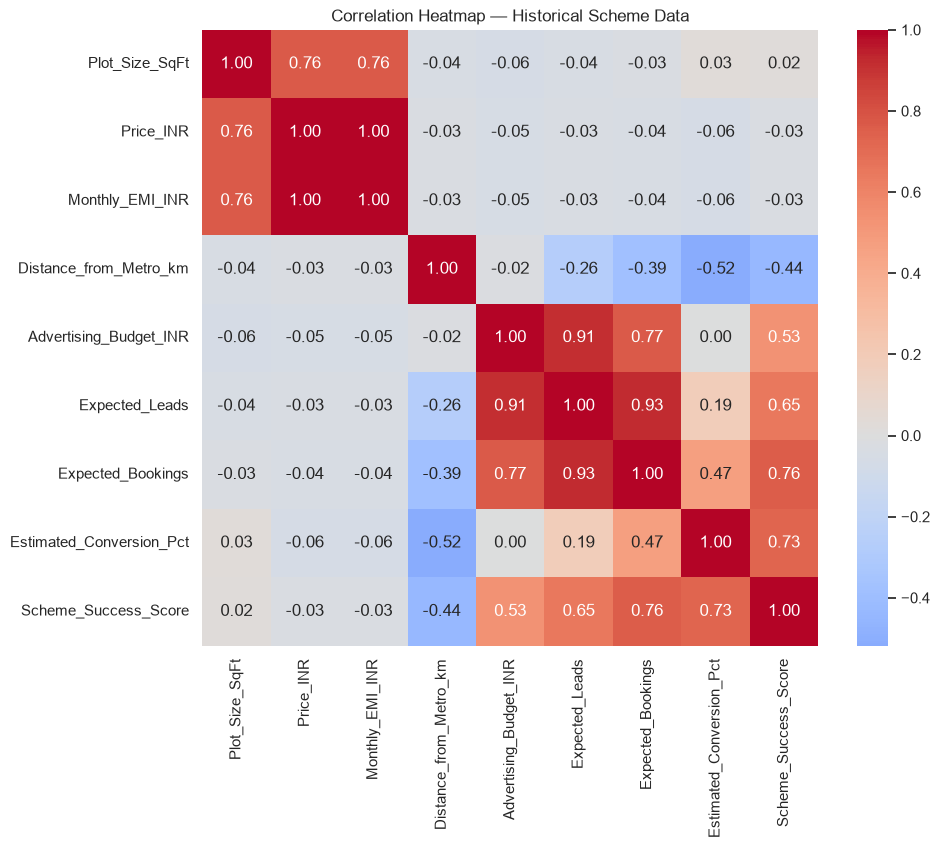

In [ ]:
numeric_cols = schemes.select_dtypes(include='number').columns
corr = schemes[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap — Historical Scheme Data')
plt.savefig('../reports/figures/heatmap(scheme).png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
corr['Scheme_Success_Score'].sort_values(ascending=False)


Scheme_Success_Score        1.000000
Expected_Bookings           0.761300
Estimated_Conversion_Pct    0.730691
Expected_Leads              0.653219
Advertising_Budget_INR      0.532892
Plot_Size_SqFt              0.019392
Price_INR                  -0.028604
Monthly_EMI_INR            -0.028633
Distance_from_Metro_km     -0.437009
Name: Scheme_Success_Score, dtype: float64

---
## Key Takeaways

1. **What drives `Scheme_Success_Score`**
   > The score correlates strongly with `Expected_Bookings` (0.76), `Estimated_Conversion_Pct`
   > (0.73), `Expected_Leads` (0.65), and `Advertising_Budget_INR` (0.53). It correlates
   > negatively with `Distance_from_Metro_km` (-0.44). But `Price_INR` and `Plot_Size_SqFt`
   > are close to 0 — price and size barely relate to success.

2. **Demand level lines up with success score**
   > Average success score is highest for **HIGH demand** schemes and lowest for
   > **LOW demand** ones — a clear, expected pattern.

3. **Clubhouse matters more than Park**
   > Schemes with a Clubhouse have a noticeably higher average success score than those
   > without. Having a Park also helps, but by a smaller margin — and most schemes in the
   > dataset already have a Park (see the pie chart), so it doesn't separate schemes as well.

4. **Being far from a metro station hurts conversion**
   > The Distance-from-Metro scatterplot shows a downward trend against price, and
   > `Distance_from_Metro_km` has a fairly strong negative correlation with
   > `Estimated_Conversion_Pct` — schemes farther from a metro tend to convert leads into
   > bookings less often.

5. **Advertising spend brings leads, not necessarily better conversion**
   > `Advertising_Budget_INR` correlates strongly with `Expected_Leads`, but only weakly
   > with `Estimated_Conversion_Pct` — more ad spend brings more leads in absolute terms,
   > but doesn't make each lead more likely to convert.

6. **Higher price doesn't mean higher success**
   > Some of the priciest locations don't have the highest success scores, and some of the
   > cheaper locations score well. Price alone isn't a good predictor of scheme success here.

**Takeaway for modelling:** funnel-related numbers (leads, bookings, conversion %) and
location/amenities explain most of the variation in success score — price and plot size
don't. If you plan to predict `Scheme_Success_Score`, be careful that
`Expected_Bookings`/`Estimated_Conversion_Pct` aren't already "giving away" the answer.
